In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("breast-cancer.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [3]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

In [4]:
# =============================================================================
# DATASET INFORMATION
# =============================================================================
#
# Dataset Name:
# Breast Cancer Wisconsin (Diagnostic) Dataset
#
# Goal:
# Predict whether a breast tumor is:
#   M -> Malignant (Cancerous)
#   B -> Benign (Non-Cancerous)
#
# The features are extracted from a Fine Needle Aspiration (FNA) image
# of a breast mass using image processing techniques.
#
# There are:
#   - 30 numerical features
#   - 1 target column (diagnosis)
#   - 1 ID column
#
# The 30 features are formed by measuring 10 properties in 3 different ways:
#
#   Mean      -> Average measurement
#   SE        -> Standard Error (variation in measurement)
#   Worst     -> Largest (worst) observed value
#
# Total Features:
#   10 × 3 = 30
#
# =============================================================================

In [5]:
# =============================================================================
# FEATURE DESCRIPTION
# =============================================================================

# radius
# -------
# Distance from the center of the nucleus to its boundary.
# Larger radius generally indicates larger cells.
# Cancer cells often have larger nuclei.

# texture
# --------
# Measures variation in pixel intensity (gray levels).
# Higher texture means the cell surface appears rougher.

# perimeter
# ----------
# Total boundary length of the nucleus.
# Irregular cancer cells usually have larger perimeters.

# area
# ----
# Area occupied by the nucleus.
# Larger area can indicate abnormal cell growth.

# smoothness
# ----------
# Measures how smooth the boundary of the nucleus is.
# Lower smoothness indicates a more irregular boundary.

# compactness
# -----------
# Measures how compact or dense the nucleus shape is.
# Formula:
#     (Perimeter² / Area) - 1
# Higher values generally indicate irregular cell shapes.

# concavity
# ---------
# Measures the severity of inward curves (indentations)
# in the nucleus boundary.
# Cancer cells usually have higher concavity.

# concave_points
# --------------
# Counts the number of inward boundary points.
# Malignant cells generally contain more concave points.

# symmetry
# --------
# Measures how symmetric the nucleus is.
# Healthy cells tend to be more symmetric.

# fractal_dimension
# -----------------
# Measures boundary complexity.
# Rough and irregular boundaries have larger fractal dimensions.

# =============================================================================

In [6]:
# =============================================================================
# FEATURE GROUPS
# =============================================================================

# Mean Features
# -------------
# Represent the average value of each property.

# radius_mean
# texture_mean
# perimeter_mean
# area_mean
# smoothness_mean
# compactness_mean
# concavity_mean
# concave points_mean
# symmetry_mean
# fractal_dimension_mean


# Standard Error Features (SE)
# ----------------------------
# Represent the variation (uncertainty) of each measurement.

# radius_se
# texture_se
# perimeter_se
# area_se
# smoothness_se
# compactness_se
# concavity_se
# concave points_se
# symmetry_se
# fractal_dimension_se


# Worst Features
# --------------
# Largest (worst) value observed for each measurement.
# These often help distinguish malignant tumors.

# radius_worst
# texture_worst
# perimeter_worst
# area_worst
# smoothness_worst
# compactness_worst
# concavity_worst
# concave points_worst
# symmetry_worst
# fractal_dimension_worst

# =============================================================================

In [7]:
# =============================================================================
# TARGET VARIABLE
# =============================================================================

# diagnosis
#
# M -> Malignant (Cancerous)
# B -> Benign (Non-Cancerous)

# Later:
# M -> 1
# B -> 0

# =============================================================================

Initial Data Inspection

In [8]:
df.shape

(569, 32)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [10]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [ ]:
# Compare raw std vs coefficient of variation across features
summary = df.describe().T[['mean', 'std']]
summary['cv'] = summary['std'] / summary['mean'] 
summary.sort_values('cv', ascending=False).head(10)

,mean,std,cv
id,3.037183e+07,1.250206e+08,4.116333
area_se,4.033708e+01,4.549101e+01,1.127771
concavity_se,3.189372e-02,3.018606e-02,0.946458
concavity_mean,8.879932e-02,7.971981e-02,0.897753
concave points_mean,4.891915e-02,3.880284e-02,0.793204
concavity_worst,2.721885e-01,2.086243e-01,0.766470
perimeter_se,2.866059e+00,2.021855e+00,0.705448
compactness_se,2.547814e-02,1.790818e-02,0.702884
fractal_dimension_se,3.794904e-03,2.646071e-03,0.697270
radius_se,4.051721e-01,2.773127e-01,0.684432


In [12]:
df.dtypes

id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [13]:
# # Data Cleaning
# 1. Check Missing Values
# 2. Check Duplicate Rows
# 3. Check Duplicate Columns (optional but good practice)
# 4. Check Unique Values of Target Variable
# 5. Drop Unnecessary Columns (id)
# 6. Verify Final Shape 

In [14]:
# Missing value : 
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [15]:
# Missing values in descending order
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing_values.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
id,0,0.0
diagnosis,0,0.0
radius_mean,0,0.0
texture_mean,0,0.0
perimeter_mean,0,0.0
area_mean,0,0.0
smoothness_mean,0,0.0
compactness_mean,0,0.0
concavity_mean,0,0.0
concave points_mean,0,0.0


In [16]:
# duplicates 
df.duplicated().sum()

np.int64(0)

In [17]:
df.drop(columns="id").duplicated().sum()
# since id uniquely identify the each row so we excluded the id to check there are duplicates or not. 

np.int64(0)

In [18]:
# check duplicate column 
df.columns.duplicated().sum()

np.int64(0)

In [19]:
# value count of target variables : 
print(df["diagnosis"].value_counts())
print(df["diagnosis"].value_counts(normalize=True))
print(df["diagnosis"].value_counts(normalize=True)*100)

diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [20]:
# creating dataframe to display bothe count and percentage 
count = df["diagnosis"].value_counts()
percentage = round(df["diagnosis"].value_counts(normalize=True)*100,2)

summary = pd.concat([count,percentage], axis=1)
summary.columns = ["count", "percentage"]
print(summary)

           count  percentage
diagnosis                   
B            357       62.74
M            212       37.26


In [21]:
# drop id column : 
df_main = df
df = df.drop("id", axis=1)

In [22]:
print(df.head())
print(df.shape)

  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.00     1203.0   
3         M        11.42         20.38           77.58      386.1   
4         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...         25.38          17.33 

In [23]:
# EDA Roadmap
# --------------------------------------
# 1. Target Variable Analysis
# 2. Univariate Analysis
# 3. Distribution Analysis
# 4. Outlier Detection
# 5. Relationship with Target
# 6. Correlation Analysis
# 7. Multicollinearity

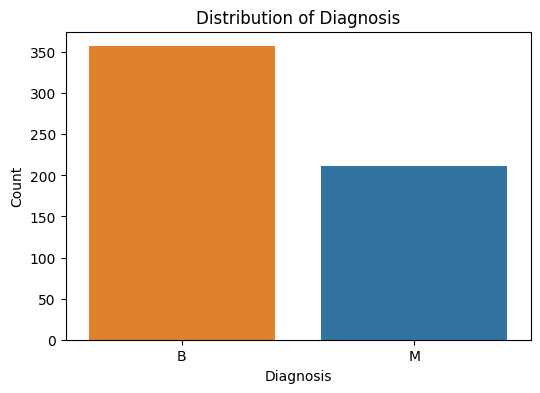

In [ ]:
#Target variable analysis : 
plt.figure(figsize=(6,4))
sns.countplot(data=df,
               x="diagnosis",
               hue="diagnosis",
               order=df["diagnosis"].value_counts().index)
plt.title("Distribution of Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

In [25]:
diagnosis_percent = round(
    df['diagnosis'].value_counts(normalize=True)*100,
    2
)

print(diagnosis_percent)

diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


In [26]:
# Step 2: Univariate Analysis (Group-wise)


In [27]:
mean_features = [col for col in df.columns if "_mean" in col]
se_features = [col for col in df.columns if "_se" in col]
worst_features = [col for col in df.columns if "_worst" in col]

print("Mean Features :", len(mean_features))
print("SE Features :", len(se_features))
print("Worst Features :", len(worst_features))

Mean Features : 10
SE Features : 10
Worst Features : 10


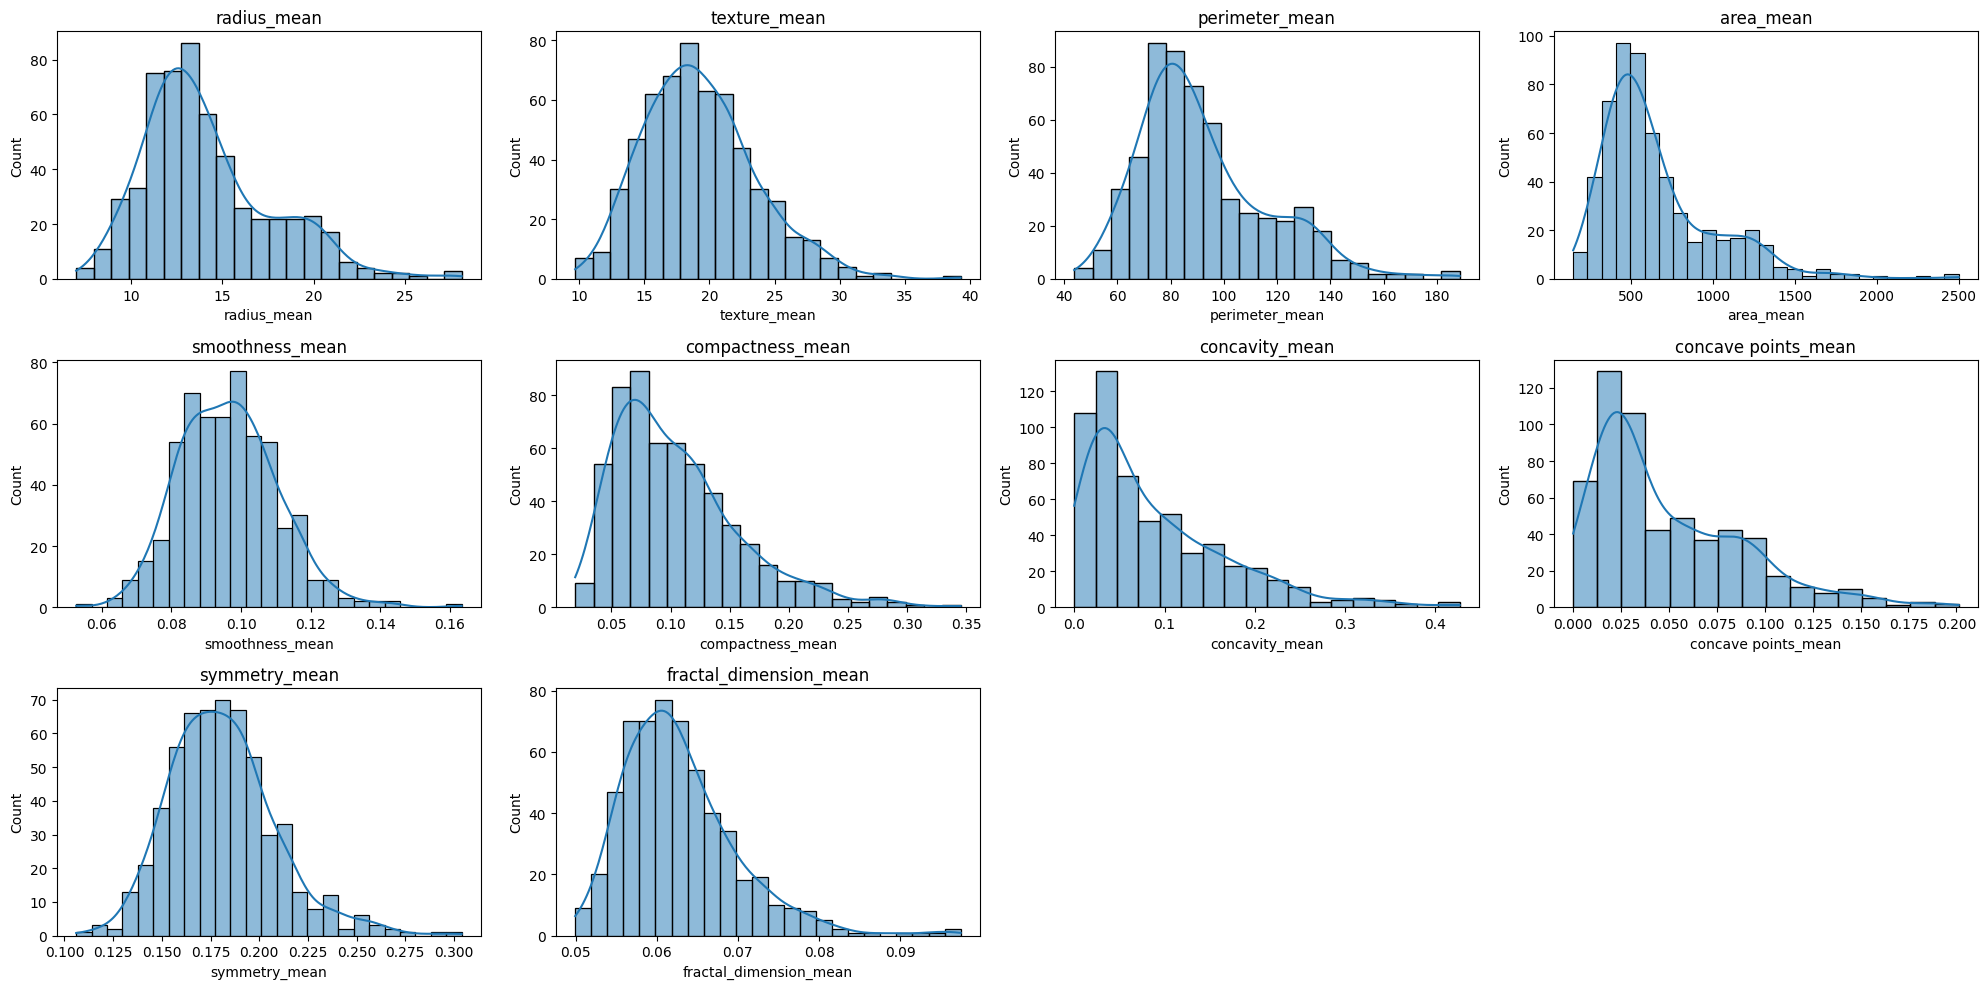

In [28]:
plt.figure(figsize=(20,10))
for i, feature in enumerate(mean_features):
    plt.subplot(3,4,i+1) # in plt.subplot indexis starts from 1 and for indexing starts from 0 so to match both index
    sns.histplot(df[feature],kde=True)
    plt.title(feature)
plt.tight_layout()
plt.show()

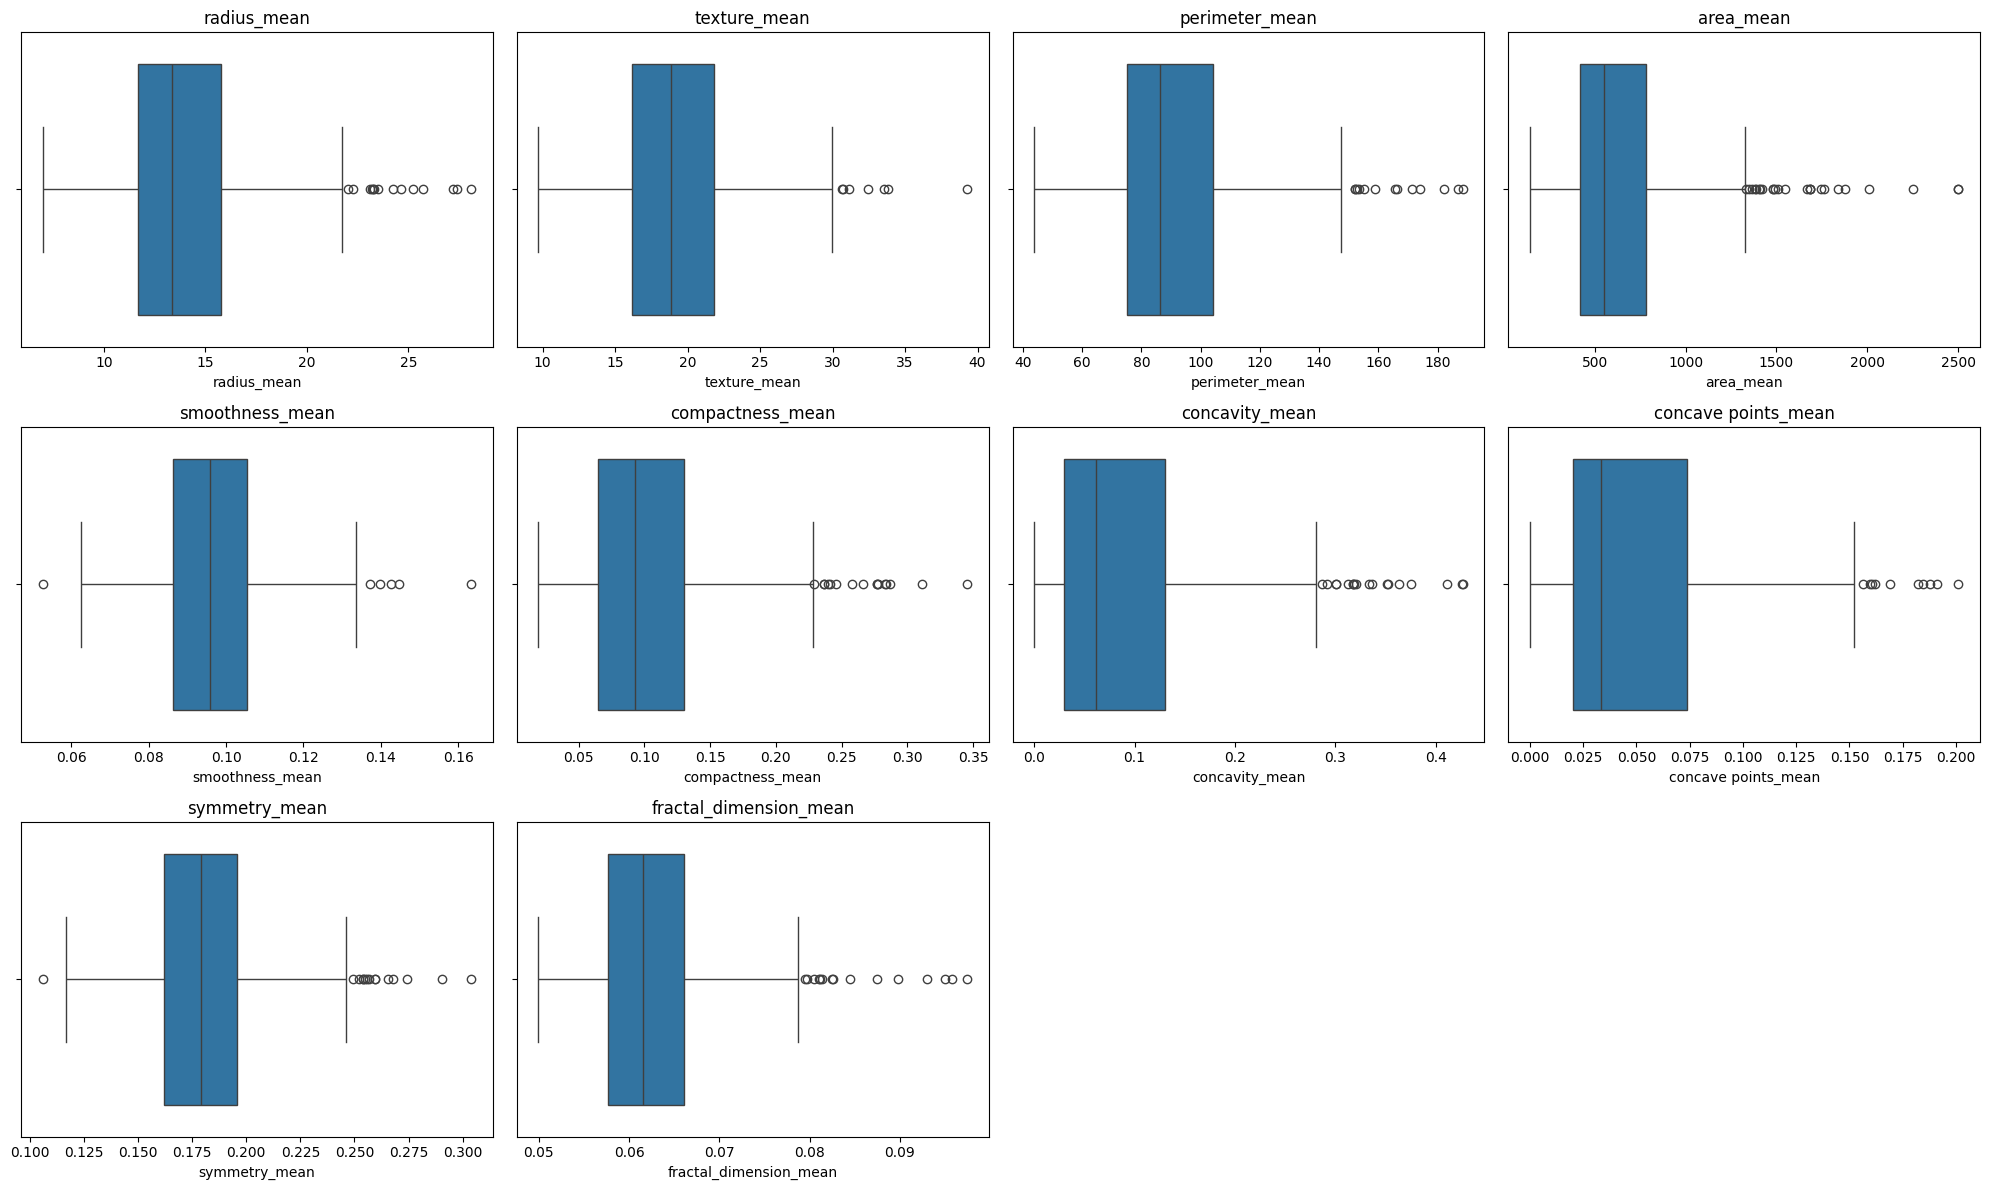

In [29]:
plt.figure(figsize=(20,12))

for i, feature in enumerate(mean_features):
    plt.subplot(3,4,i+1)
    sns.boxplot(x=df[feature])
    plt.title(feature)

plt.tight_layout()
plt.show()

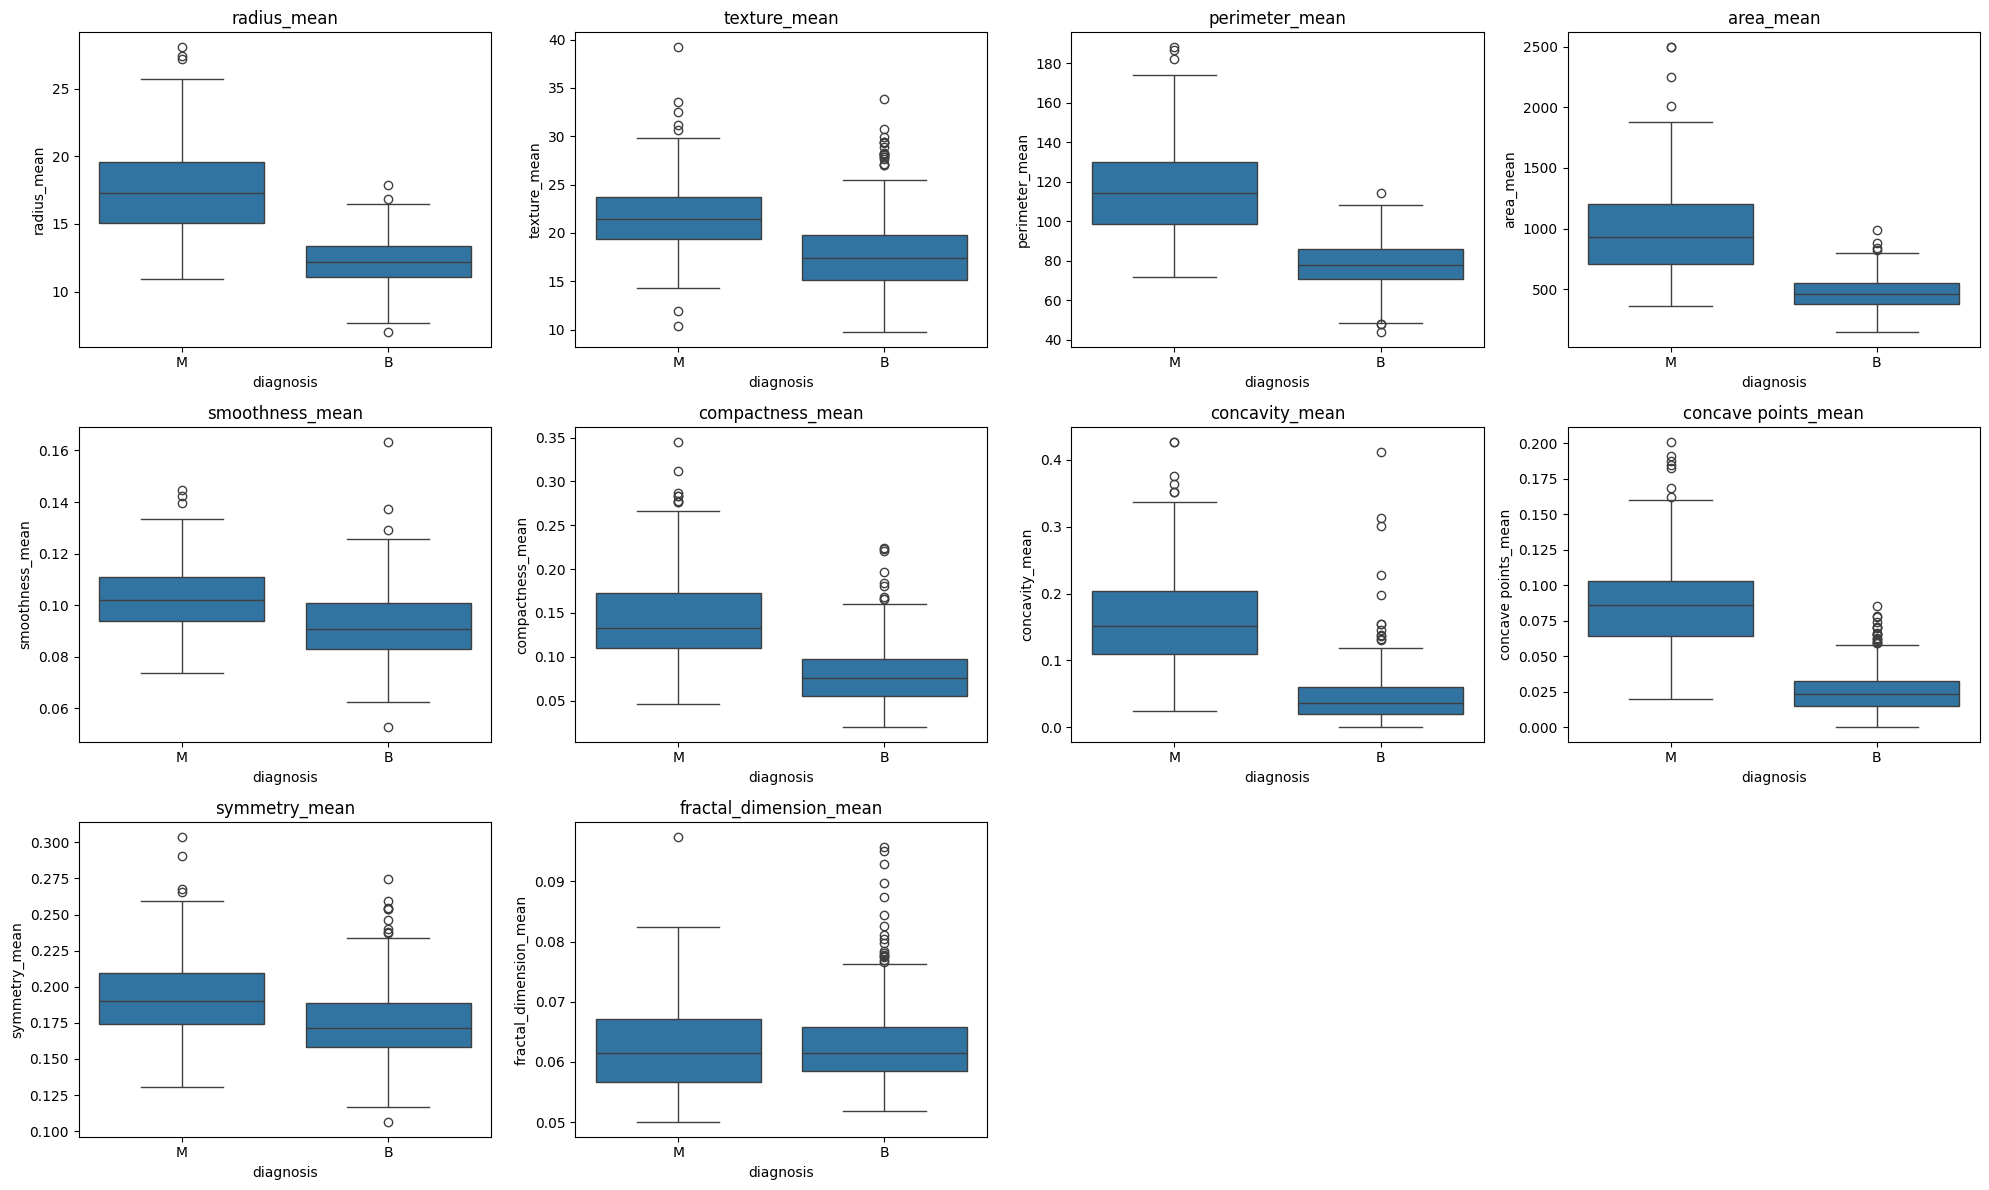

'\nThis draws two separate boxes side by side (one for B, one for M) — exactly the same "split by target" idea \nyou did with histograms via hue. Worth remembering for your Step 5 revisit later — boxplots split by class are\n often more useful than split histograms for quickly\n'

In [30]:
# Relationship with Target
plt.figure(figsize=(20, 12))

for i, feature in enumerate(mean_features):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(data=df, x="diagnosis", y=feature)
    plt.title(feature)

plt.tight_layout()
plt.show()
"""
This draws two separate boxes side by side (one for B, one for M) — exactly the same "split by target" idea 
you did with histograms via hue. Worth remembering for your Step 5 revisit later — boxplots split by class are
 often more useful than split histograms for quickly
"""

In [31]:
"""
almost every graph has : Median(M) > Median(B)
->Meaning
Malignant tumors generally have
    larger radius
    larger perimeter
    larger area
    greater concavity
    greater compactness
    more concave points
"""

'\nalmost every graph has : Median(M) > Median(B)\n->Meaning\nMalignant tumors generally have\n    larger radius\n    larger perimeter\n    larger area\n    greater concavity\n    greater compactness\n    more concave points\n'

<Axes: xlabel='diagnosis', ylabel='radius_mean'>

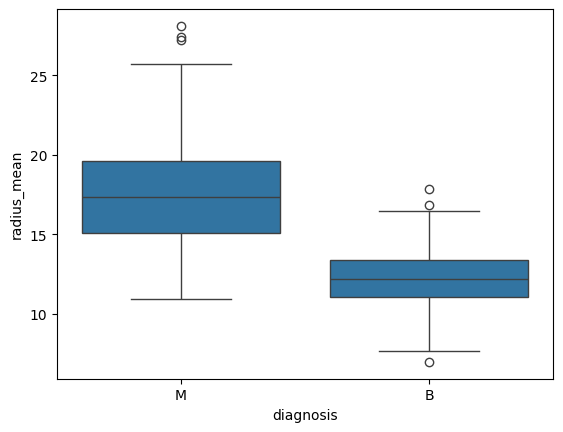

In [32]:
# let select some cases from above and see how to read the box plot
sns.boxplot(data=df, x ="diagnosis", y="radius_mean")

In [33]:
"""
Question 1
Which class has the higher median?
from above graph : ✅ Malignant tumors have a much larger average radius 
=>Malignant tumors generally have a larger radius than benign tumors.

Question 2
Do the boxes overlap?

they hardly overlaps, 
Note: little overlap means this feature separate the two class well 

Question 3
How different are the medians?

They're far apart.
The farther apart,
the easier the classifier's job.
"""

"\nQuestion 1\nWhich class has the higher median?\nfrom above graph : ✅ Malignant tumors have a much larger average radius \n=>Malignant tumors generally have a larger radius than benign tumors.\n\nQuestion 2\nDo the boxes overlap?\n\nthey hardly overlaps, \nNote: little overlap means this feature separate the two class well \n\nQuestion 3\nHow different are the medians?\n\nThey're far apart.\nThe farther apart,\nthe easier the classifier's job.\n"

<Axes: xlabel='diagnosis', ylabel='fractal_dimension_mean'>

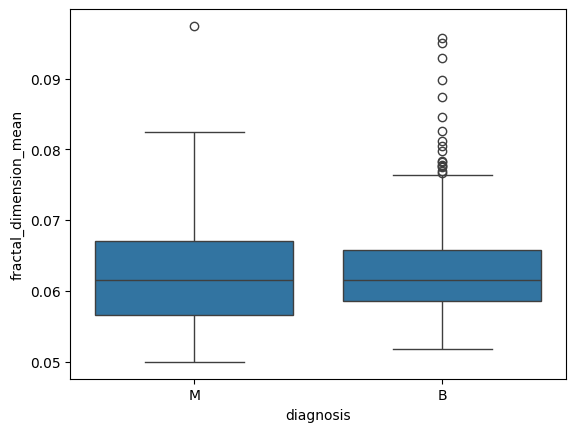

In [34]:
sns.boxplot(data=df, x="diagnosis", y="fractal_dimension_mean")

In [35]:
"""
Median(M) is almost near to Median(B)
Both overlap almost complete 

-> QUE:if we hide the lable can i guess the patient is Malignant =>> answer is NO because both class is almost identical
-> therfore : fractal_dimension_mean is a weak feature for distinguishing between benign and malignant tumors.
"""

'\nMedian(M) is almost near to Median(B)\nBoth overlap almost complete \n\n-> QUE:if we hide the lable can i guess the patient is Malignant =>> answer is NO because both class is almost identical\n-> therfore : fractal_dimension_mean is a weak feature for distinguishing between benign and malignant tumors.\n'

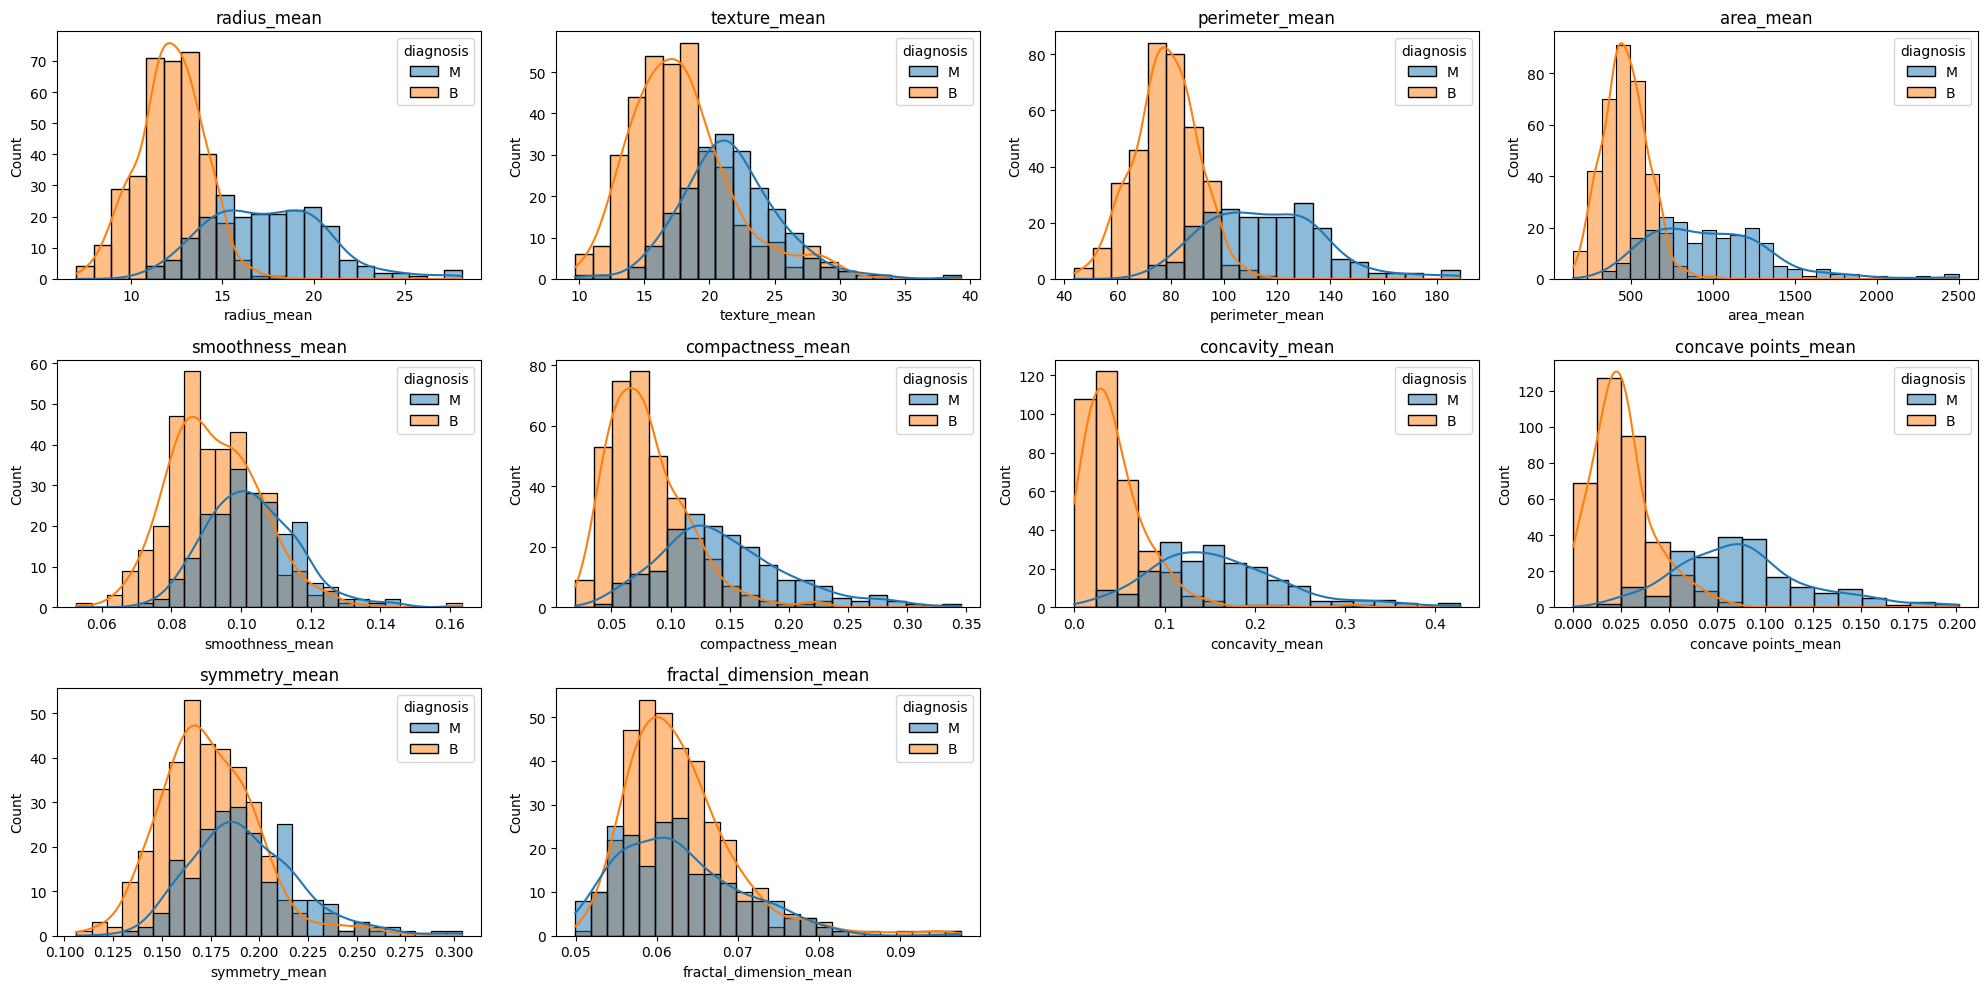

In [ ]:
plt.figure(figsize=(20,10))
for i, feature in enumerate(mean_features):
    plt.subplot(3, 4, i + 1)  # plt.subplot indexing starts from 1 and python from 0 so to match idx we used i+1
    sns.histplot(data=df,
                  x=feature,
                    hue='diagnosis',
                      kde=True)
    plt.title(feature)
plt.tight_layout()
plt.show()

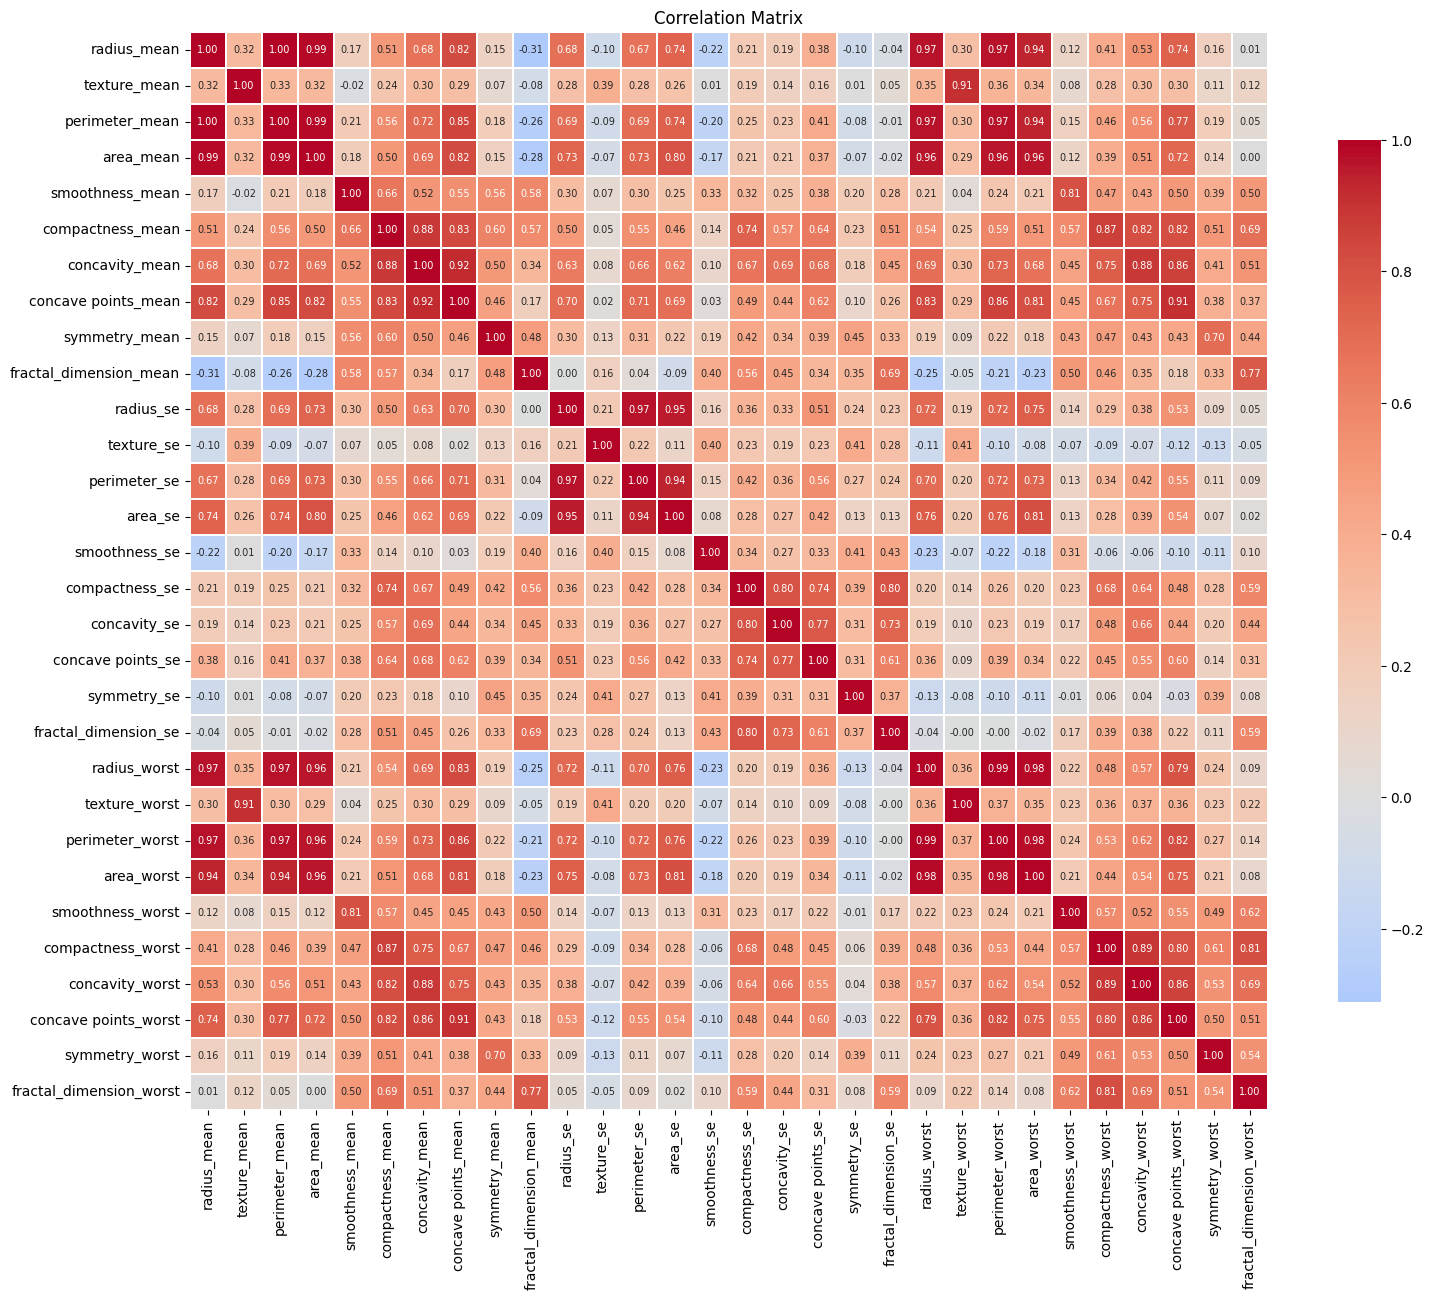

In [37]:
# Correlation Analysis
plt.figure(figsize=(18,14))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,          # show the actual correlation numbers
    fmt=".2f",           # round to 2 decimal places (0.87 instead of 0.8734829...)
    annot_kws={"size": 7},  # small font so 900→~435 numbers still fit
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix")
plt.show()

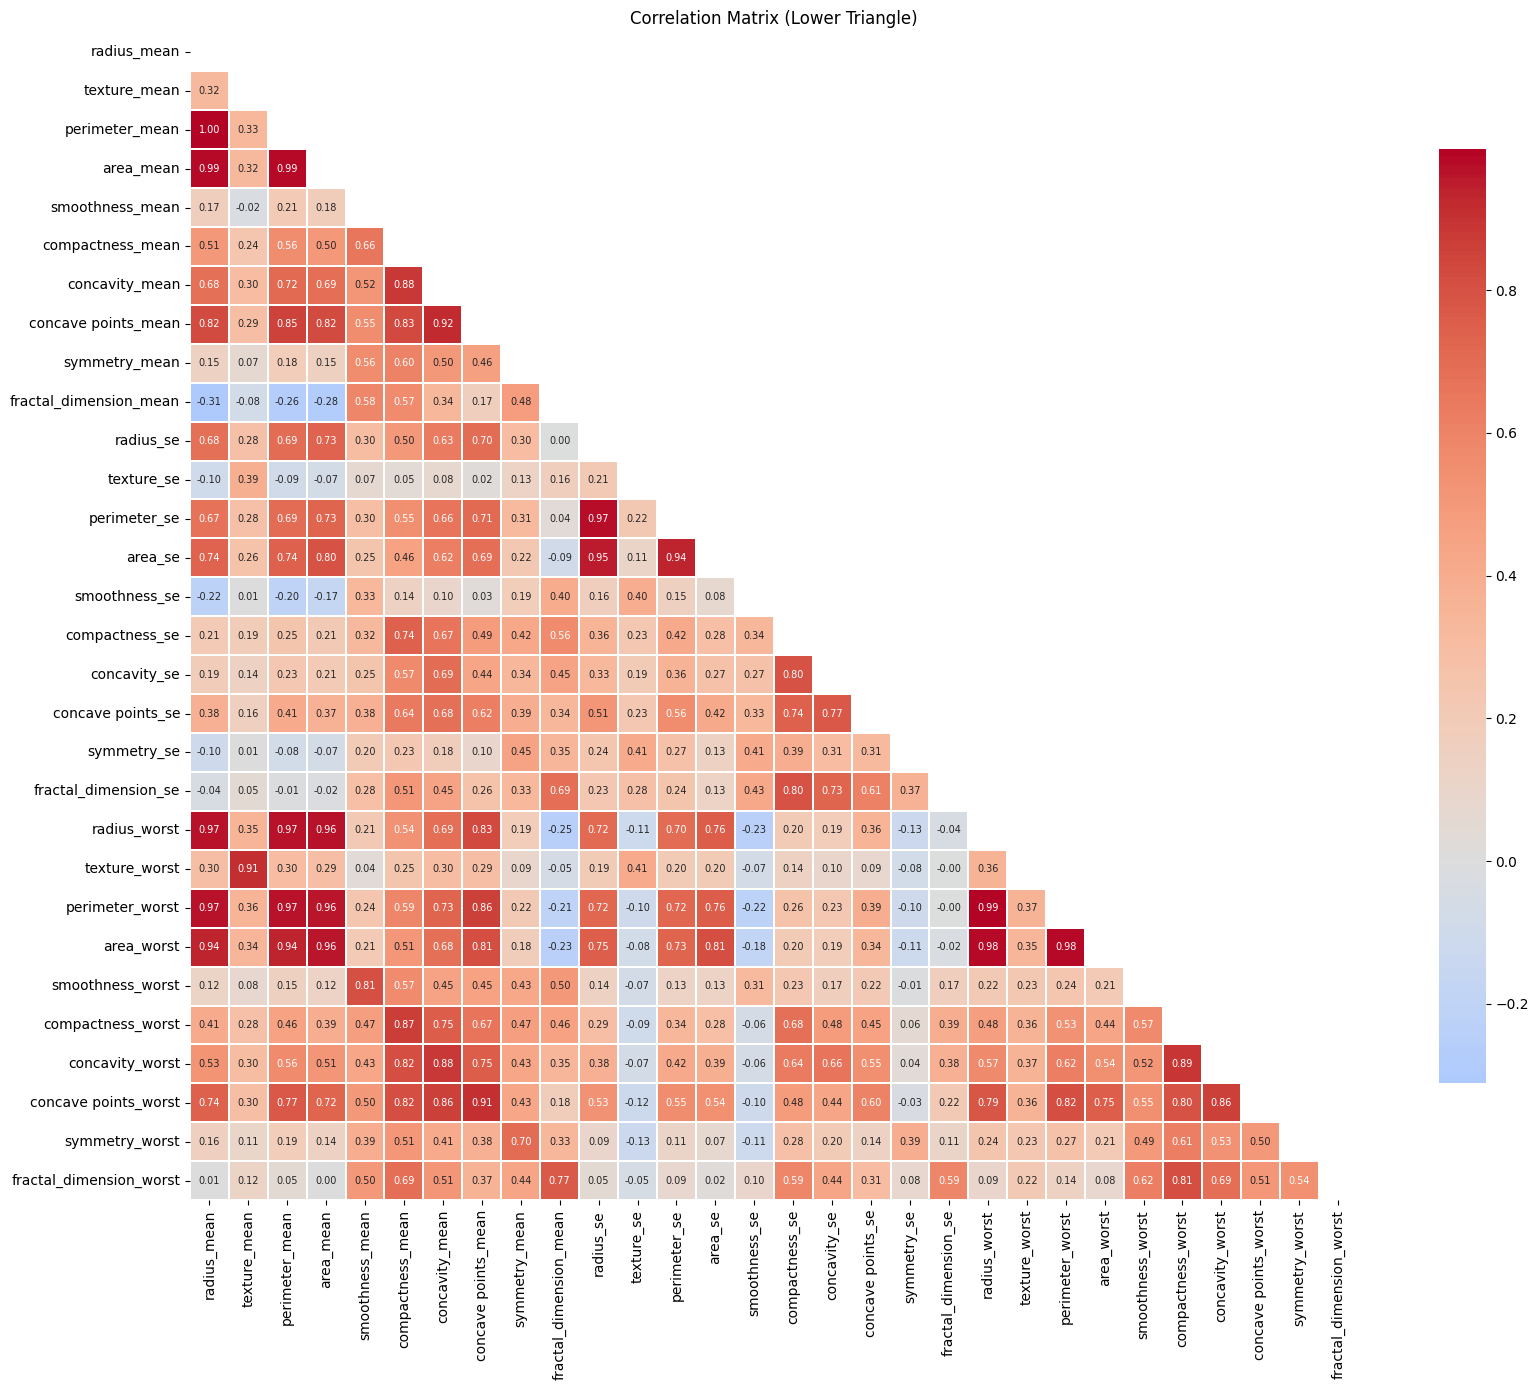

In [38]:
import numpy as np

plt.figure(figsize=(18, 14))

correlation_matrix = df.corr(numeric_only=True)

# Build a mask: True = hide this cell
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,          # show the actual correlation numbers
    fmt=".2f",           # round to 2 decimal places (0.87 instead of 0.8734829...)
    annot_kws={"size": 7},  # small font so 900→~435 numbers still fit
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix (Lower Triangle)")
plt.tight_layout()
plt.show()

In [ ]:
# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Convert correlation matrix into a table
corr_pairs = corr_matrix.unstack()
# print(corr_pairs)
# print(corr_pairs.index)
# print(corr_pairs.shape)

# # Remove duplicate pairs
corr_pairs = corr_pairs.drop_duplicates()
# print(corr_pairs.shape)

# # Remove self-correlation (correlation = 1)
corr_pairs = corr_pairs[corr_pairs != 1]
# print(corr_pairs.shape)

# # Sort by absolute correlation (abs() give absolute value of integer)
# corr_pairs.abs().sort_values(ascending=False).index
corr_pairs = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)
# print(corr_pairs)

# # Display highly correlated pairs
high_corr = corr_pairs[abs(corr_pairs) > 0.80]

high_corr

radius_mean          perimeter_mean             0.997855
radius_worst         perimeter_worst            0.993708
radius_mean          area_mean                  0.987357
perimeter_mean       area_mean                  0.986507
radius_worst         area_worst                 0.984015
perimeter_worst      area_worst                 0.977578
radius_se            perimeter_se               0.972794
perimeter_mean       perimeter_worst            0.970387
radius_mean          radius_worst               0.969539
perimeter_mean       radius_worst               0.969476
radius_mean          perimeter_worst            0.965137
area_mean            radius_worst               0.962746
                     area_worst                 0.959213
                     perimeter_worst            0.959120
radius_se            area_se                    0.951830
perimeter_mean       area_worst                 0.941550
radius_mean          area_worst                 0.941082
perimeter_se         area_se   

In [ ]:
# Multicolinerarity : 

In [41]:
from  statsmodels.stats.outliers_influence import variance_inflation_factor
# we have to work on independent variable only 
X = df.drop("diagnosis", axis = 1)


vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values,i) for i in range(len(X.columns))
]
vif = vif.sort_values("VIF", ascending=False)
vif

,Feature,VIF
0,radius_mean,63306.172036
2,perimeter_mean,58123.586079
20,radius_worst,9674.742602
22,perimeter_worst,4487.781270
3,area_mean,1287.262339
23,area_worst,1138.759252
9,fractal_dimension_mean,629.679874
29,fractal_dimension_worst,423.396723
4,smoothness_mean,393.398166
24,smoothness_worst,375.597155


**Phase 2: Preprocessing & Model Building**

In [42]:
# 1. Feature & Target Separation
# 2. Train-Test Split
# 3. Feature Scaling  (Most Important for SVM)
# 4. Train Baseline SVM
# 5. Model Evaluation
# 6. Hyperparameter Tuning
# 7. Compare Different Kernels
# 8. Final Model

In [43]:
df.diagnosis.dtype

<StringDtype(storage='python', na_value=nan)>

In [44]:
print(df["diagnosis"].head())
df["diagnosis"] = df["diagnosis"].map({
    "B": 0,
    "M": 1
})
print(df["diagnosis"].head())



0    M
1    M
2    M
3    M
4    M
Name: diagnosis, dtype: str
0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64


In [45]:
# feature and target seperation
X = df.drop("diagnosis", axis=1)
y= df["diagnosis"]
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [46]:
# train test split 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=1,
    shuffle=True,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
# "stratify=y ensures that the class distribution in both the training and testing sets "
# "remains similar to the original dataset. This is particularly important for classification"
# " problems, especially when the classes are imbalanced."

(455, 30)
(114, 30)
(455,)
(114,)


In [47]:
# Preprocessing : scaling 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
pd.DataFrame(X_train_scaled, columns=X.columns).describe().round(2)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,455.00,455.00,455.00,455.00,455.00,455.00,455.00,455.00,455.00,455.00,...,455.00,455.00,455.00,455.00,455.00,455.00,455.00,455.00,455.00,455.00
mean,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,...,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.04,-2.22,-1.99,-1.47,-3.13,-1.52,-1.11,-1.26,-2.75,-1.79,...,-1.72,-2.18,-1.68,-1.21,-2.71,-1.43,-1.28,-1.73,-2.15,-1.60
25%,-0.69,-0.75,-0.69,-0.67,-0.76,-0.73,-0.74,-0.74,-0.70,-0.72,...,-0.67,-0.77,-0.69,-0.64,-0.67,-0.71,-0.76,-0.77,-0.64,-0.69
50%,-0.20,-0.09,-0.20,-0.28,-0.01,-0.20,-0.37,-0.39,-0.09,-0.21,...,-0.27,-0.06,-0.28,-0.34,-0.04,-0.26,-0.23,-0.21,-0.13,-0.24
75%,0.46,0.60,0.48,0.36,0.63,0.47,0.56,0.67,0.52,0.48,...,0.51,0.70,0.51,0.33,0.60,0.53,0.52,0.72,0.45,0.44
max,3.80,3.37,3.92,5.31,4.77,4.41,4.12,3.62,4.51,4.86,...,4.05,3.83,4.22,5.84,4.00,4.95,4.50,2.62,6.01,6.74


In [49]:
"""after scaling mean becomes zero because we use Zscore formula for scaling and 
in formula we substract Xi with mean(X bar) so when we separate mean - mean it becomes 0 
and 
std = 1 because, let say original std is sigma and std measure: number of standard 
deviations away from the mean. But we divide every value by sigma(std) so after scaling 
std become 1"""

'after scaling mean becomes zero because we use Zscore formula for scaling and \nin formula we substract Xi with mean(X bar) so when we separate mean - mean it becomes 0 \nand \nstd = 1 because, let say original std is sigma and std measure: number of standard \ndeviations away from the mean. But we divide every value by sigma(std) so after scaling \nstd become 1'

In [50]:
#Training 
from sklearn.svm import SVC
svc_linear = SVC(kernel="linear")


In [51]:
# svc.get_params()  by default kernal is rbf if you don't do kernal = "linear" 

In [52]:
svc_linear.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [53]:
y_pred = svc_linear.predict(X_test_scaled)

In [54]:
y_pred

array([1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1])

In [55]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9649122807017544

In [56]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[70  2]
 [ 2 40]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        72
           1       0.95      0.95      0.95        42

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



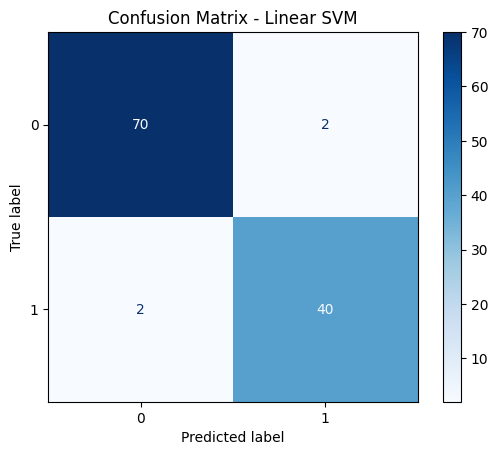

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    svc_linear,
    X_test_scaled,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Linear SVM")
plt.show()

In [58]:
print("Support Vectors per class:", svc_linear.n_support_)
print("Total Support Vectors:", len(svc_linear.support_))

Support Vectors per class: [20 17]
Total Support Vectors: 37


In [59]:
#Hyperparameter tuning 
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = [
    {
        "kernel": ["linear"],
        "C": [0.01, 0.1, 1, 10, 100]
    },

    {
        "kernel": ["rbf"],
        "C": [0.01, 0.1, 1, 10, 100],
        "gamma": ["scale", "auto", 0.001, 0.01, 0.1]
    },

    {
        "kernel": ["poly"],
        "C": [0.01, 0.1, 1, 10],
        "degree": [2, 3, 4],
        "gamma": ["scale", "auto"]
    }
]

In [61]:
grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1,
    verbose=2,
    refit=True
)

In [62]:
grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.01, 0.1, ...], 'kernel': ['linear']}, {'C': [0.01, 0.1, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['rbf']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is d

In [63]:
print(grid_search.best_params_)

{'C': 1, 'kernel': 'linear'}


In [64]:
print(grid_search.best_score_)

0.9647058823529413


In [65]:
print(grid_search.best_estimator_)

SVC(C=1, kernel='linear')


In [66]:
result = pd.DataFrame(grid_search.cv_results_)
result

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,param_gamma,param_degree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.025124,0.006161,0.026011,0.004416,0.01,linear,NaN,NaN,"{'C': 0.01, 'kernel': 'linear'}",0.941176,0.794118,0.823529,1.000000,0.911765,0.894118,0.075789,20
1,0.022340,0.006694,0.028858,0.009608,0.10,linear,NaN,NaN,"{'C': 0.1, 'kernel': 'linear'}",0.970588,0.911765,0.882353,1.000000,0.941176,0.941176,0.041595,14
2,0.015861,0.002671,0.020649,0.001971,1.00,linear,NaN,NaN,"{'C': 1, 'kernel': 'linear'}",1.000000,0.970588,0.882353,0.970588,1.000000,0.964706,0.043226,1
3,0.027013,0.008036,0.021134,0.005584,10.00,linear,NaN,NaN,"{'C': 10, 'kernel': 'linear'}",0.970588,0.911765,0.882353,0.911765,0.970588,0.929412,0.035294,15
4,0.094777,0.075771,0.020925,0.005307,100.00,linear,NaN,NaN,"{'C': 100, 'kernel': 'linear'}",0.970588,0.911765,0.882353,0.911765,0.970588,0.929412,0.035294,15
5,0.057405,0.005835,0.051101,0.010943,0.01,rbf,scale,NaN,"{'C': 0.01, 'gamma': 'scale', 'kernel': 'rbf'}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50
6,0.041624,0.005332,0.035171,0.012036,0.01,rbf,auto,NaN,"{'C': 0.01, 'gamma': 'auto', 'kernel': 'rbf'}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50
7,0.040504,0.009768,0.045246,0.012603,0.01,rbf,0.001,NaN,"{'C': 0.01, 'gamma': 0.001, 'kernel': 'rbf'}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50
8,0.049770,0.012609,0.037710,0.007299,0.01,rbf,0.01,NaN,"{'C': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50
9,0.043795,0.009387,0.038802,0.006353,0.01,rbf,0.1,NaN,"{'C': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50


In [67]:
results = pd.DataFrame(grid_search.cv_results_)

results = results[
    [
        "param_kernel",
        "param_C",
        "param_gamma",
        "param_degree",
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
    ]
]

results = results.sort_values("rank_test_score")

results.head(15)


,param_kernel,param_C,param_gamma,param_degree,mean_test_score,std_test_score,rank_test_score
2,linear,1.0,NaN,NaN,0.964706,0.043226,1
15,rbf,1.0,scale,NaN,0.958824,0.051281,2
24,rbf,10.0,0.1,NaN,0.958824,0.051281,2
23,rbf,10.0,0.01,NaN,0.958824,0.044019,2
20,rbf,10.0,scale,NaN,0.958824,0.044019,2
21,rbf,10.0,auto,NaN,0.958824,0.044019,2
19,rbf,1.0,0.1,NaN,0.958824,0.051281,2
16,rbf,1.0,auto,NaN,0.958824,0.051281,2
29,rbf,100.0,0.1,NaN,0.958824,0.051281,2
26,rbf,100.0,auto,NaN,0.952941,0.047788,10


In [68]:
""""
refit=True
means the best model is already trained.

So we don't need to create another SVC().

"""

'"\nrefit=True\nmeans the best model is already trained.\n\nSo we don\'t need to create another SVC().\n\n'

In [69]:
y_pred_best = grid_search.best_estimator_.predict(X_test_scaled)

In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision :", precision_score(y_test, y_pred_best))
print("Recall :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

Accuracy : 0.9649122807017544
Precision : 0.9523809523809523
Recall : 0.9523809523809523
F1 Score : 0.9523809523809523


In [71]:
cm = confusion_matrix(y_test, y_pred_best)
print(cm)

[[70  2]
 [ 2 40]]


In [72]:
classification_report(y_test,y_pred_best)

'              precision    recall  f1-score   support\n\n           0       0.97      0.97      0.97        72\n           1       0.95      0.95      0.95        42\n\n    accuracy                           0.96       114\n   macro avg       0.96      0.96      0.96       114\nweighted avg       0.96      0.96      0.96       114\n'